## Grouped Titles Dimensionality Reduction

Using includes method with keywords may be powerful to help reduce number of unique job titles without us having to do manual mappings. Can also use key phrases here. just investigating to see if any common words/phrases arise to help us do further grouping.

In [ ]:
import os
os.getcwd()
#os.chdir("/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
#jobs = pd.read_csv("fake_job_postings.csv")
jobs = pd.read_csv("jobs_clean.csv")

In [4]:
vals = jobs["Grouped_Titles"].value_counts()
vals

Grouped_Titles
English Teacher Abroad                                         490
Customer Service Associate                                     198
Software Engineering                                           155
Graduates: English Teacher Abroad (Conversational)             144
Customer Service Associate - Part Time                          91
                                                              ... 
Prop Stylist (Temporary position: Nov '13 - Feb '14)             1
Sales Executive - Office Equipment                               1
QA/QC Leader - Cured Meats Co - Chicagoland                      1
Application Developer/SQL Server                                 1
Project Cost Control Staff Engineer - Cost Control Exp - TX      1
Name: count, Length: 10909, dtype: int64

In [5]:
most_common = vals[vals > 25]
len(most_common)

35

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34],
 [Text(0, 0, 'English Teacher Abroad'),
  Text(1, 0, 'Customer Service Associate'),
  Text(2, 0, 'Software Engineering'),
  Text(3, 0, 'Graduates: English Teacher Abroad (Conversational)'),
  Text(4, 0, 'Customer Service Associate - Part Time'),
  Text(5, 0, 'Account Manager'),
  Text(6, 0, 'Project Manager'),
  Text(7, 0, 'Web Developer'),
  Text(8, 0, 'Customer Service Representative'),
  Text(9, 0, 'Beauty & Fragrance consultants needed'),
  Text(10, 0, 'Graduates: English Teacher Abroad'),
  Text(11, 0, 'Administrative Assistant'),
  Text(12, 0, 'Sales Representative'),
  Text(13, 0, 'Product Manager'),
  Text(14, 0, 'Customer Service Team Lead'),
  Text(15, 0, 'Account Executive'),
  Text(16, 0, 'Marketing Manager'),
  Text(17, 0, 'Office Manager'),
  Text(18, 0, 'Senior Software Eng

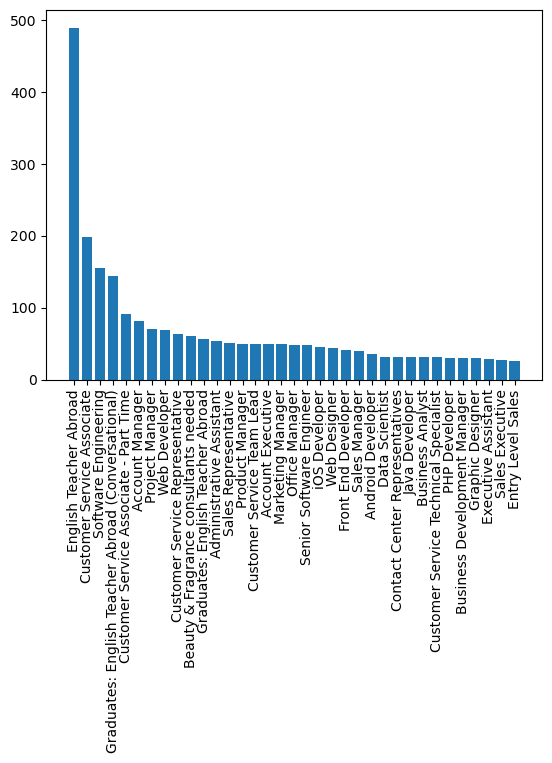

In [6]:
plt.bar(most_common.index, most_common.values)
plt.xticks(rotation=90)

In [7]:
#most_common

In [8]:
from collections import Counter
import pandas as pd

# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings

# Tokenize the text and count word frequencies
all_words = ' '.join(grouped_titles).split()  # Combine all titles and split into words
word_counts = Counter(all_words)  # Count occurrences of each word

# Get the most common keywords
most_common_keywords = word_counts.most_common(50)  # Top 20 most common words

# Display the results
print("Most Common Keywords in Grouped_Titles:")
for word, count in most_common_keywords:
    print(f"{word}: {count}")

Most Common Keywords in Grouped_Titles:
Manager: 2062
-: 1951
Developer: 1581
Engineer: 1415
Sales: 1233
Senior: 941
Customer: 936
Service: 862
Teacher: 773
English: 771
Marketing: 747
Abroad: 693
Software: 646
Associate: 627
Assistant: 602
/: 587
Designer: 544
&: 537
and: 532
Business: 503
Web: 493
Account: 485
Specialist: 484
Executive: 463
Representative: 443
Analyst: 440
Director: 412
of: 400
Development: 364
Lead: 355
Product: 344
Project: 337
Support: 334
Data: 330
for: 325
Engineering: 289
Consultant: 267
Intern: 261
Operations: 253
Technical: 247
NAS: 244
Junior: 234
Time: 233
16-18: 226
Administrator: 218
Office: 217
Digital: 211
Technician: 210
Coordinator: 205
Graduates:: 204


# Most Common 2 word phrases

Can also look at most common phrases in Grouped_Titles (like 2 words together)

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings

# Use CountVectorizer to extract bigrams (2-word phrases)
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
bigrams = vectorizer.fit_transform(grouped_titles)

# Sum the occurrences of each bigram
bigram_counts = bigrams.sum(axis=0)
bigram_frequencies = [(phrase, bigram_counts[0, idx]) for phrase, idx in vectorizer.vocabulary_.items()]
bigram_frequencies = sorted(bigram_frequencies, key=lambda x: x[1], reverse=True)

# Display the top 20 most common bigrams
print("Top 20 Most Common 2-Word Phrases in Grouped_Titles:")
for phrase, count in bigram_frequencies[:50]:
    print(f"{phrase}: {count}")

Top 20 Most Common 2-Word Phrases in Grouped_Titles:
customer service: 741
english teacher: 720
teacher abroad: 691
service associate: 343
software engineer: 304
year olds: 278
web developer: 265
18 year: 246
sales representative: 231
account manager: 231
16 18: 226
nas 16: 224
project manager: 219
business development: 211
graduates english: 204
account executive: 187
marketing manager: 170
software engineering: 164
end developer: 163
sales manager: 151
abroad conversational: 145
product manager: 129
data entry: 129
inside sales: 128
apprenticeship nas: 124
associate time: 107
entry level: 107
administrative assistant: 104
senior software: 104
ux designer: 102
sales executive: 100
java developer: 97
office manager: 97
ios developer: 92
social media: 91
net developer: 87
service representative: 87
php developer: 87
web designer: 86
business analyst: 81
team lead: 80
sales professional: 78
development manager: 78
application developer: 77
software developer: 77
fragrance consultants: 73

Now could use "includes" methods with these words to further filter down, and include only above a certain count (threshold)